In [11]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

In [12]:
spikes_df = pd.read_parquet('../data/bin/spikes/spikes.parquet')
spikes_df

,subj,sess,hemi,region,neur_id,base_start,base_stop,spike_times
0,CS58,P58CSR1,Left,ACC,P58CS_R1_1_1_994_6,478.847432,531.161099,"[7.00682475, 10.84863625, 19.2006645, 19.27744..."
1,CS58,P58CSR1,Right,ACC,P58CS_R1_35_2_2425_5,478.847432,531.161099,"[8.0925435, 9.68744875, 11.07738625, 11.54073,..."
2,CS58,P58CSR1,Right,ACC,P58CS_R1_35_1_2195_5,478.847432,531.161099,"[8.01138725, 11.5975425, 13.11694775, 13.27707..."
3,CS58,P58CSR1,Right,ACC,P58CS_R1_34_4_3301_5,478.847432,531.161099,"[0.0645465, 0.19526525, 0.4629215, 0.7165465, ..."
4,CS58,P58CSR1,Right,ACC,P58CS_R1_34_3_3299_5,478.847432,531.161099,"[0.03082775, 0.10876525, 0.9559215, 2.45320175..."
...,...,...,...,...,...,...,...,...
1452,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_3_3847_7,478.834214,531.051037,"[0.18107825, 0.7991095, 1.02176575, 1.20795325..."
1453,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_2_3846_7,478.834214,531.051037,"[0.03289075, 0.1451095, 0.178672, 0.2311095, 0..."
1454,CS62,P62CSR1,Right,preSMA,P62CS_R1_18_1_3830_7,478.834214,531.051037,"[76.092017, 76.9399535, 79.0344525, 79.9236087..."
1455,CS62,P62CSR1,Right,vmPFC,P62CS_R1_7_1_791_9,478.834214,531.051037,"[2.0504835, 3.396921, 4.78307625, 7.4743565, 1..."


In [16]:
def get_rates_by_time(spikes_df, bin_dur):
    
    enc_stop = spikes_df['base_start'][0]
    bin_edges = np.arange(0, enc_stop + bin_dur, bin_dur)
    time_by_rates = np.zeros((len(bin_edges)-1,
                              len(spikes_df)))

    col_names = []

    for id, neur in spikes_df.iterrows():

        col_name = neur['hemi'] + '_' + neur['region'] + '_' + neur['neur_id']
        col_names.append(col_name)

        # get rates per bin
        spike_counts, _ = np.histogram(neur['spike_times'], bins=bin_edges)
        rate = spike_counts / bin_dur

        # norm by baseline activity
        # rate_normed = (rate - neur['base_FR_mean']) / neur['base_FR_std']
        
        time_by_rates[:, id] = rate

    return(pd.DataFrame(time_by_rates, columns=col_names))

In [ ]:
rates_by_time = get_rates_by_time(spikes_df, bin_dur=.3)
rates_by_time

,Left_ACC_P58CS_R1_1_1_994_6,Right_ACC_P58CS_R1_35_2_2425_5,Right_ACC_P58CS_R1_35_1_2195_5,Right_ACC_P58CS_R1_34_4_3301_5,Right_ACC_P58CS_R1_34_3_3299_5,Right_ACC_P58CS_R1_34_2_3239_5,Right_ACC_P58CS_R1_34_1_3232_5,Right_ACC_P58CS_R1_36_1_712_5,Right_ACC_P58CS_R1_36_2_962_5,Right_ACC_P58CS_R1_38_1_1473_5,...,Right_amygdala_P62CS_R1_28_1_6059_3,Right_amygdala_P62CS_R1_27_3_8498_3,Right_preSMA_P62CS_R1_22_3_2598_7,Right_preSMA_P62CS_R1_22_2_2532_7,Right_preSMA_P62CS_R1_22_1_2407_7,Right_preSMA_P62CS_R1_18_3_3847_7,Right_preSMA_P62CS_R1_18_2_3846_7,Right_preSMA_P62CS_R1_18_1_3830_7,Right_vmPFC_P62CS_R1_7_1_791_9,Right_vmPFC_P62CS_R1_5_1_1374_9
0,0.0,0.000000,0.0,6.666667,6.666667,3.333333,0.000000,0.000000,3.333333,0.000000,...,0.0,0.0,6.666667,0.0,0.000000,3.333333,20.000000,0.000000,0.0,0.000000
1,0.0,0.000000,0.0,3.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.0,0.000000,0.000000,10.000000,0.000000,0.0,6.666667
2,0.0,0.000000,0.0,6.666667,0.000000,0.000000,0.000000,3.333333,0.000000,3.333333,...,0.0,0.0,0.000000,0.0,0.000000,3.333333,10.000000,0.000000,0.0,0.000000
3,0.0,0.000000,0.0,0.000000,3.333333,0.000000,0.000000,0.000000,0.000000,3.333333,...,0.0,0.0,3.333333,0.0,0.000000,3.333333,0.000000,0.000000,0.0,0.000000
4,0.0,0.000000,0.0,6.666667,0.000000,0.000000,0.000000,0.000000,3.333333,3.333333,...,0.0,0.0,0.000000,0.0,0.000000,10.000000,6.666667,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,0.0,0.000000,0.0,20.000000,0.000000,0.000000,3.333333,0.000000,3.333333,0.000000,...,0.0,0.0,0.000000,0.0,3.333333,0.000000,0.000000,0.000000,0.0,0.000000
1593,0.0,3.333333,0.0,33.333333,3.333333,3.333333,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.0,0.000000,0.000000,3.333333,0.000000,0.0,3.333333
1594,0.0,0.000000,0.0,13.333333,3.333333,0.000000,3.333333,0.000000,0.000000,0.000000,...,0.0,0.0,3.333333,0.0,0.000000,0.000000,0.000000,3.333333,0.0,3.333333
1595,0.0,0.000000,0.0,20.000000,0.000000,0.000000,0.000000,3.333333,3.333333,0.000000,...,0.0,0.0,0.000000,0.0,0.000000,0.000000,3.333333,0.000000,0.0,3.333333


## comparing plots to PS54CS_R2

plotting all 123 neurons, EVEN THOSE WITH 16S PERIODS OF MISSING DATA


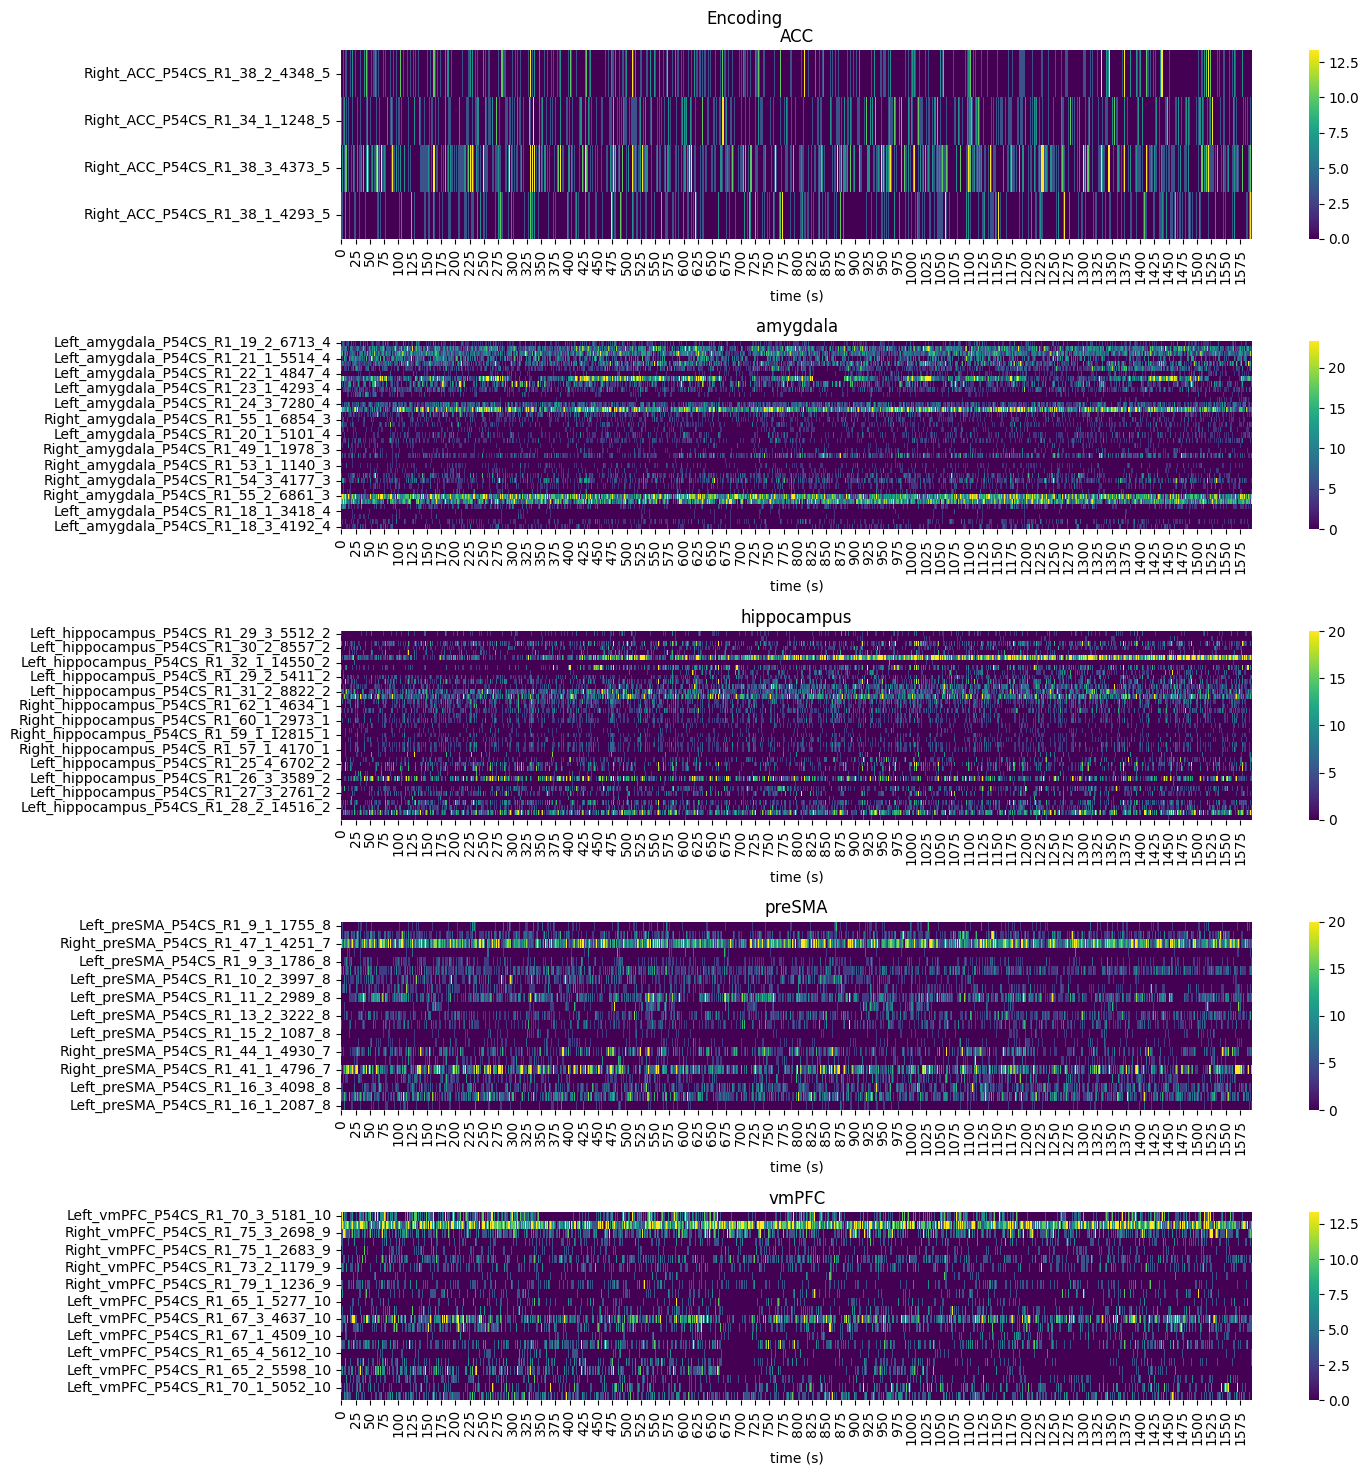

In [31]:
sess = 'P54CS_R1'
sess_cols = [col for col in rates_by_time.columns if sess in col]
print(f'plotting all {len(sess_cols)} neurons, EVEN THOSE WITH 16S PERIODS OF MISSING DATA')
sess_df = rates_by_time[sess_cols]

regions = sorted(set([col.split('_')[1] for col in sess_cols]))

fig, axs = plt.subplots(5, 1, figsize=(15, 15))
axs, ax = axs.flatten(), 0

for region in regions:

    region_cols = [col for col in sess_df.columns if region in col]
    sess_reg_df = sess_df[region_cols].T

    sns.heatmap(sess_reg_df, cmap='viridis', cbar=True, ax=axs[ax], vmax = np.percentile(sess_reg_df.values, 99))
    axs[ax].set(xlabel='time (s)', title = region)
    ax += 1

plt.suptitle('Encoding')

plt.tight_layout()
plt.show()